**Deep learning**
---

when mL fails deep learing comes into play.
It mimics human brain.


neurons- basic building blocks.

weights- how strong the connection is.


output-- summation of (wixi)



Activation function
---
if the activation function is - 0 then it means the neuron is turned off

---
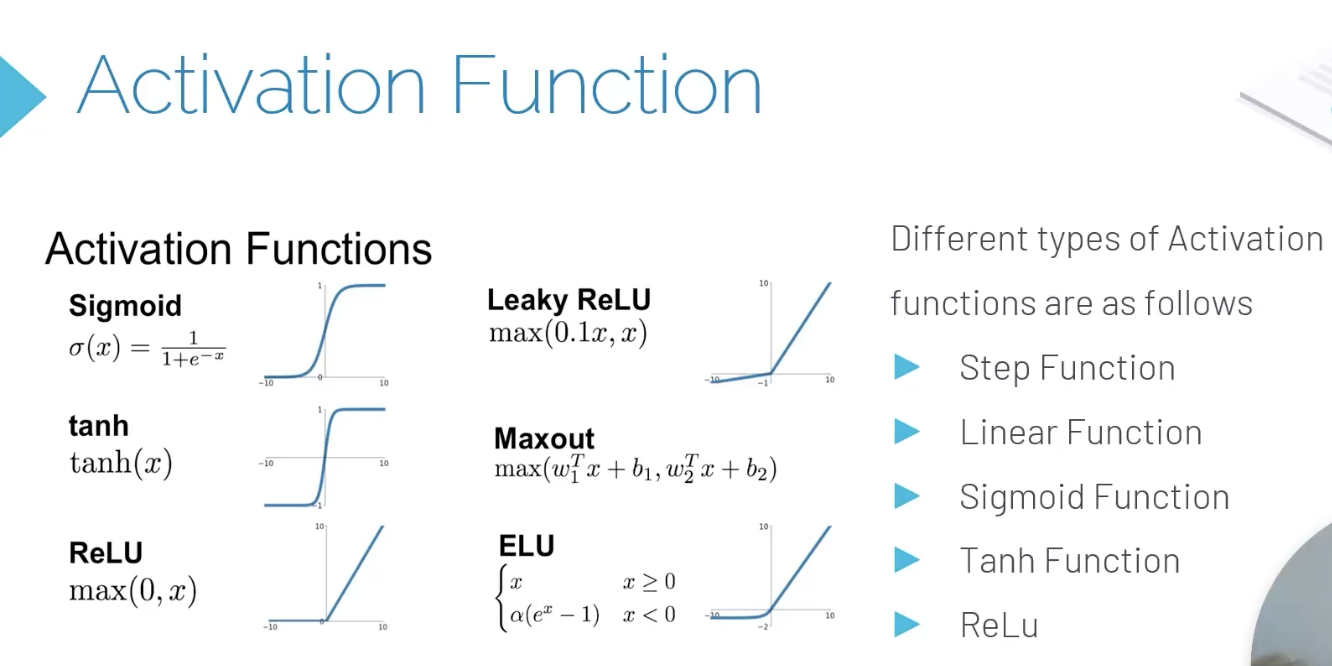

**Step function**- threshold based activation function, above a point neuron activated else not activated.

used mostly in binary classification problem

---
**Linear function**-
y=mx+c

gradient- delta y/ delta x= change in y by change in x

---
**tanh**= 2 times sigmoid function - 1

range (-1,1)

---
**ReLu function** -

rectified linear function
 A(x) is max of (0, num)

 overall its non linear. for hidden layers maybe its better than sigmoid.

 Dying relu problem-- coz in the left side neurons r not activated, gradient is 0( change in y is 0)

 leaky relu- y is not 0 but very small value. to make gradient non 0.

 ---


Gradinet descent means- decreasing gradient

**Backward prop and forward pass**
---

one flow of forward pass and backward-- is called iteration

---

1. randomly initialize the model
2. input first obser
3. frwd prop frm left to right
4. compare that to y and calc the cost function
5. then back prop frm right to left
6. repeat 1 to 5 till we finalise model-->batch learning or reinforcemet learning


ANN- artificial neural network
---

traditional machine learning-

1. Install libraries & importing them
2. Importing dataset
3. Data Preprocessing
4. Feature Scaling
5. Feature Extraction
6. Splitting data into train & test
7. Fitting the classifier to training data
8. Predictions
9. Analyzing predictions with actual test data

---
in ANN step #4 to #6 is replaced by:

- Initializing ANN
- Adding input, hidden & output layers
- Compiling the ANN
- Fitting the ANN to the training dataset

In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")

print("Dataset Path:", path)

dataset = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))

# Features and target
X = dataset.iloc[:, 3:13].values
y = dataset.iloc[:, 13].values

print(X)
print(y)

Using Colab cache for faster access to the 'churn-modellingcsv' dataset.
Dataset Path: /kaggle/input/churn-modellingcsv
[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]
[1 0 1 ... 1 1 0]


In [8]:
dataset.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
len(dataset)

10000

In [10]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [11]:
len(X_test)

2000

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode Geography column
le1 = LabelEncoder()
X_train[:, 1] = le1.fit_transform(X_train[:, 1])
X_test[:, 1] = le1.transform(X_test[:, 1])

# Encode Gender column
le2 = LabelEncoder()
X_train[:, 2] = le2.fit_transform(X_train[:, 2])
X_test[:, 2] = le2.transform(X_test[:, 2])

# Feature Scaling
sc = StandardScaler()

X_train = sc.fit_transform(X_train.astype(float))
X_test = sc.transform(X_test.astype(float))

In [13]:
# Classical ML
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

In [14]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)
print(cm)

[[1364  231]
 [ 193  212]]


In [15]:
#Making the Confusion Matrix
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, pred)
print(score*100)

78.8


**Accuracy from Decision Tree Classifier:80%**
---



In [16]:
#Classical ML
from sklearn.ensemble import RandomForestClassifier
c1f = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)
pred2 = clf.predict(X_test)

In [17]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)
print(cm)

[[1364  231]
 [ 193  212]]


In [18]:
#Making the Confusion Matrix
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, pred)
print(score*100)

78.8


**Accuracy from Decision Tree Classifier: 80%**
---

In [19]:
#Random Forest
# Classical ML
from sklearn.ensemble import RandomForestClassifier

clf2 = RandomForestClassifier(n_estimators=100)

clf2.fit(X_train, y_train)

pred2 = clf2.predict(X_test)

In [20]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred2)
print(cm)

[[1526   69]
 [ 201  204]]


In [21]:
from sklearn.metrics import accuracy_score

score2=accuracy_score(y_test, pred2)
print(score2*100)

86.5


**Accuracy from Random Forest Classfier: 87%**


# **ANN**

In [22]:
pip install keras

In [23]:
pip install tensorflow

In [24]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [25]:
classifier = Sequential()
#units: It's an art, comes by experience, input+output/2
#initializer: how your weights are updated
#relu activation function
#input_dim: input shape (shape of the data, how many features do we have in the data)
# Adding the input layer and the first hidden layer
classifier.add(Dense (units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 10))
# Adding the second hidden layer
classifier.add(Dense (units = 6, kernel_initializer = 'uniform', activation = 'relu'))
# Adding the third hidden layer
classifier.add(Dense (units = 6, kernel_initializer = 'uniform', activation = 'relu'))
# Adding the output layer
classifier.add(Dense (units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
len(X_train)

8000

In [27]:
# Compiling the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
y_train[0]
# Fitting the ANN to the Training set
classifier.fit(X_train, y_train, batch_size = 10, epochs = 50)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7961 - loss: 0.4901
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7960 - loss: 0.4349
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7960 - loss: 0.4281
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8167 - loss: 0.4238
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8232 - loss: 0.4208
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8288 - loss: 0.4182
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8294 - loss: 0.4174
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8299 - loss: 0.4157
Epoch 9/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8306 - loss: 0.4140
Epoch 10/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8311 - loss: 0.4127
Epoch 11/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8335 - loss: 0.4109
Epoch 12/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [28]:
# Part 3 -Making predictions and evaluating the model
# Predicting the Test set results
y_pred_ann = classifier.predict(X_test)
y_pred_ann = (y_pred_ann > 0.5)
cm3 = confusion_matrix(y_test, y_pred_ann)
print(cm3)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1538   57]
 [ 255  150]]


In [29]:
# Making the Confusion Matrix
from sklearn.metrics import accuracy_score
score3 = accuracy_score(y_test,y_pred_ann)
print(score3*100)

84.39999999999999


Accuracy from ANN: 84%

**Conclusion:**
So, as we have already seen, by using 2 hidden layered ANN, we aren't able to get beyond 85% accuracy, ofcourse we can get high accuracy by increasing the epochs & doing some hyperparameter tuning, so on the other hand, the classical models can also be tuned further.
Bottomline, always start with classical machine learning models, and if we aren't able to increase the performance, then move towards Deep Learning techniques :)

In [30]:
# Predicting a single new observation
"""Predict if the customer with the following informations will leave the bank:
Geography: France
Credit Score:
600
Gender: Male
Age: 40
Tenure: 3
Balance: 60000
Number of Products: 2
Has Credit Card:
Yes
Is Active Member:
Yes
Estimated Salary:
50000"""
new_prediction = classifier.predict(sc.transform(np.array([[600, 0, 1, 40, 3, 60000, 2, 1, 1, 50000]])))
new_prediction = (new_prediction > 0.5)
new_prediction
# Making the Confusion Matrix
#from sklearn.metrics import confusion_matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[False]])

In [1]:
!pip install --upgrade scikit-learn scikeras

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Encode categorical columns

le1 = LabelEncoder()
X[:, 1] = le1.fit_transform(X[:, 1])

le2 = LabelEncoder()
X[:, 2] = le2.fit_transform(X[:, 2])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# Feature Scaling
sc = StandardScaler()

X_train = sc.fit_transform(X_train.astype(float))
X_test = sc.transform(X_test.astype(float))

In [7]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN
def build_classifier():

    classifier = Sequential()

    classifier.add(Dense(
        units=6,
        kernel_initializer='uniform',
        activation='relu',
        input_shape=(10,)
    ))

    classifier.add(Dense(
        units=6,
        kernel_initializer='uniform',
        activation='relu'
    ))

    classifier.add(Dense(
        units=1,
        kernel_initializer='uniform',
        activation='sigmoid'
    ))

    classifier.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier

# KerasClassifier
classifier = KerasClassifier(
    model=build_classifier,
    batch_size=10,
    epochs=10,
    verbose=0
)

# K-Fold Validation
accuracies = cross_val_score(
    estimator=classifier,
    X=X_train,
    y=y_train,
    cv=10
)

# Mean Accuracy
print(accuracies.mean())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

0.8318749999999999


In [9]:
variance = accuracies.std()

print(variance)

0.008592329428042202


In [10]:
accuracies

array([0.8325 , 0.835  , 0.8325 , 0.8225 , 0.84625, 0.835  , 0.83125,
       0.82   , 0.82   , 0.84375])

In [11]:
# Hyperparameter Optimization for ANN

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN
def build_classifier(optimizer='adam'):

    classifier = Sequential()

    classifier.add(Dense(
        units=6,
        kernel_initializer='uniform',
        activation='relu',
        input_shape=(10,)
    ))

    classifier.add(Dense(
        units=6,
        kernel_initializer='uniform',
        activation='relu'
    ))

    classifier.add(Dense(
        units=1,
        kernel_initializer='uniform',
        activation='sigmoid'
    ))

    classifier.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier

# Keras Classifier
classifier = KerasClassifier(
    model=build_classifier,
    verbose=0
)

# Parameters for Grid Search
parameters = {
    'batch_size': [10, 20],
    'epochs': [5, 10],
    'optimizer': ['adam', 'rmsprop']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=parameters,
    scoring='accuracy',
    cv=10,
    n_jobs=1
)

# Fit Model
grid_search = grid_search.fit(X_train, y_train)

# Best Parameters
best_parameters = grid_search.best_params_

# Best Accuracy
best_accuracy = grid_search.best_score_

print("Best Parameters:", best_parameters)
print("Best Accuracy:", best_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Best Parameters: {'batch_size': 10, 'epochs': 10, 'optimizer': 'rmsprop'}
Best Accuracy: 0.8335000000000001


In [12]:
tuple1= ([2,3,4],6,7)

In [13]:
tuple1[0][1]=5

In [14]:
tuple1

([2, 5, 4], 6, 7)

Improvising the performance of ANN
---
1. Increasing the number of hidden layers
2. Increasing the number of epochs
3. Fine-tuning the parameters - optimizers, batch_size, epochs
4. Dropout regularization: Dropout(0.25)
Overfitting problem -> training accuracy increases, but test accuracy is low